# clusters — 2D embedding viewer

Renders a 2D embedding (e.g. UMAP/t-SNE) colored by cluster labels, with one storyboard slide per cluster.

```
clusters(data_or_path, labels=None, *, x_col, y_col, label_col,
         names, size, width, height, padding, interactive) -> np.ndarray | None
```

- **Slide 0** — all clusters overlaid
- **Slide i** — cluster *i-1* zoomed to its bounding box
- Press `1`–`9` to jump slides; `+`/`-` or scroll to zoom; drag to pan

Noise points (label `−1`) are rendered in grey.

In [1]:
import numpy as np
import pandas as pd
from PIL import Image
from IPython.display import display
import justviz as jv

## 1 — Synthetic Gaussian blobs (numpy arrays)

50,000 points, 5 clusters
clusters: 50,000 points (5 layers), 1024×768, render 248.9ms


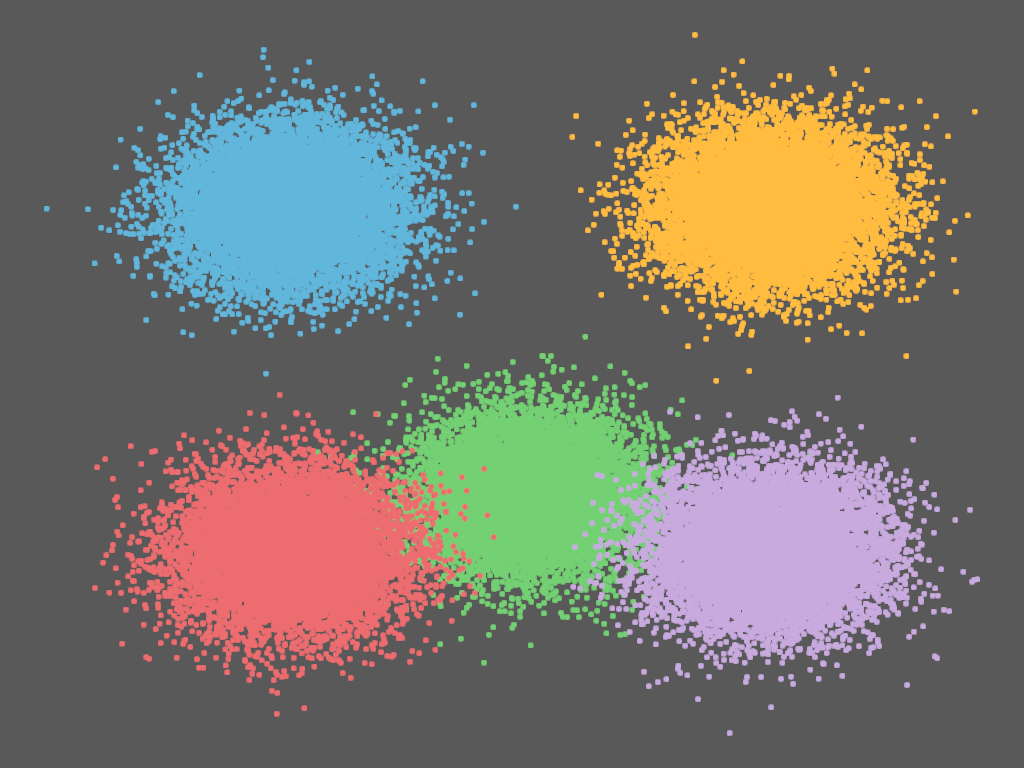

In [2]:
rng = np.random.default_rng(42)

centers = [(20, 20), (80, 20), (50, 70), (20, 80), (80, 80)]
n_per = 10_000
xs, ys, lbls = [], [], []

for i, (cx, cy) in enumerate(centers):
    xs.append(rng.normal(cx, 7, n_per).astype(np.float32))
    ys.append(rng.normal(cy, 7, n_per).astype(np.float32))
    lbls.append(np.full(n_per, i, dtype=np.int32))

embedding = np.column_stack([np.concatenate(xs), np.concatenate(ys)])
labels    = np.concatenate(lbls)

print(f"{len(labels):,} points, {len(centers)} clusters")

img = jv.clusters(embedding, labels=labels,
                  names=["Alpha", "Beta", "Gamma", "Delta", "Epsilon"],
                  size=3.0, width=1024, height=768)
display(Image.fromarray(img, mode='RGBA'))

## 2 — With noise points (label = −1)

clusters: 18,000 points (3 layers), 1024×768, render 7.6ms


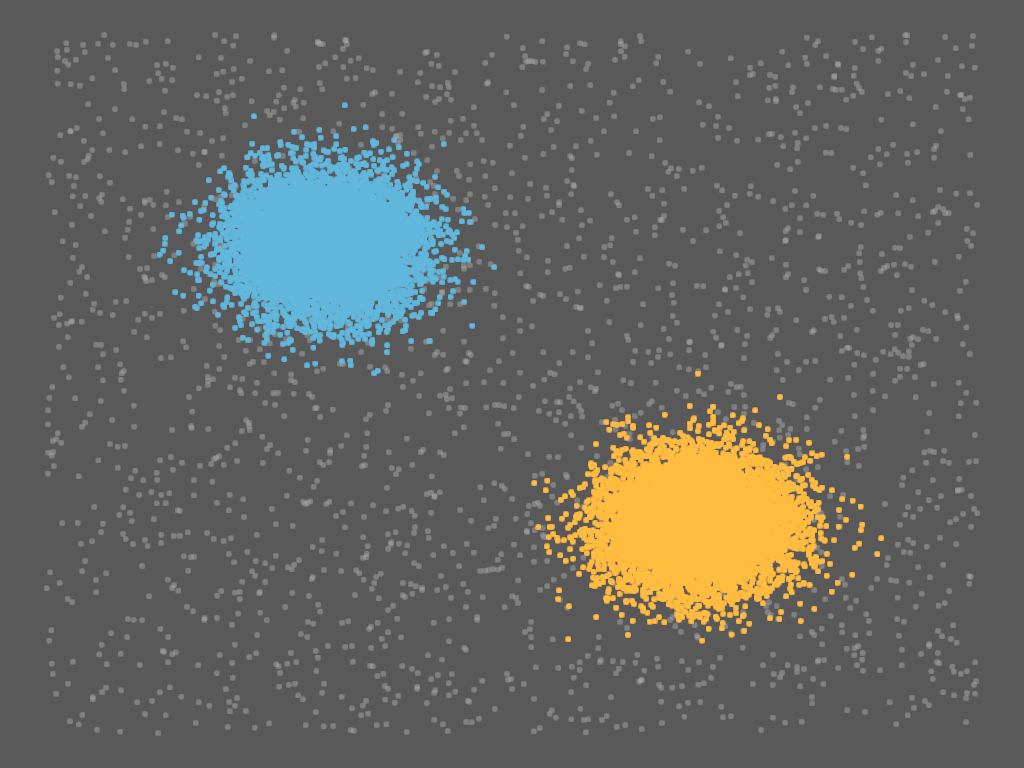

In [3]:
rng = np.random.default_rng(99)

# Core clusters
x_core = np.concatenate([
    rng.normal(30, 5, 8_000),
    rng.normal(70, 5, 8_000),
]).astype(np.float32)
y_core = np.concatenate([
    rng.normal(30, 5, 8_000),
    rng.normal(70, 5, 8_000),
]).astype(np.float32)
l_core = np.concatenate([np.zeros(8_000, dtype=np.int32), np.ones(8_000, dtype=np.int32)])

# Noise
x_noise = rng.uniform(0, 100, 2_000).astype(np.float32)
y_noise = rng.uniform(0, 100, 2_000).astype(np.float32)
l_noise = np.full(2_000, -1, dtype=np.int32)  # noise label

embedding2 = np.column_stack([np.concatenate([x_core, x_noise]),
                               np.concatenate([y_core, y_noise])])
labels2    = np.concatenate([l_core, l_noise])

img = jv.clusters(embedding2, labels=labels2,
                  names=["Cluster A", "Cluster B"],
                  size=3.0, width=1024, height=768)
display(Image.fromarray(img, mode='RGBA'))

## 3 — From a pandas DataFrame

clusters: 30,000 points (3 layers), 1024×768, render 10.5ms


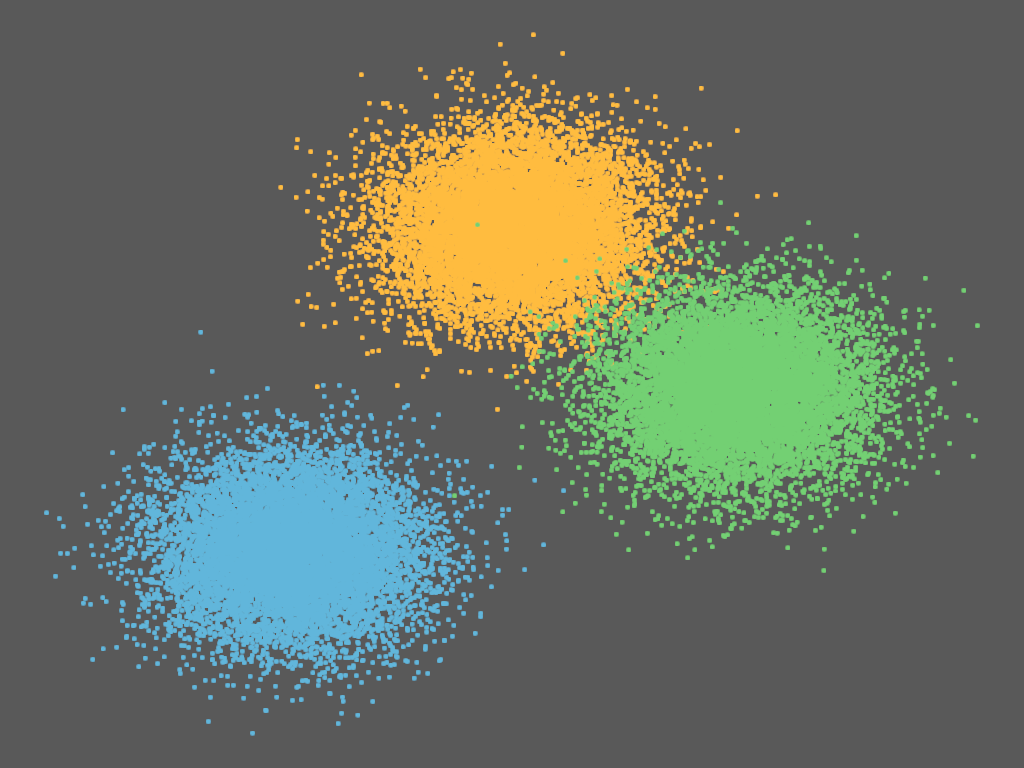

In [4]:
rng = np.random.default_rng(7)

n = 30_000
# Simulate a 2D UMAP-like embedding
x_vals = np.concatenate([
    rng.normal(-5, 1.5, n // 3),
    rng.normal( 0, 1.5, n // 3),
    rng.normal( 5, 1.5, n // 3),
]).astype(np.float32)
y_vals = np.concatenate([
    rng.normal( 5, 1.5, n // 3),
    rng.normal(-5, 1.5, n // 3),
    rng.normal( 0, 1.5, n // 3),
]).astype(np.float32)
cluster_ids = np.concatenate([
    np.zeros(n // 3, dtype=np.int32),
    np.ones(n // 3,  dtype=np.int32),
    np.full(n // 3, 2, dtype=np.int32),
])

df = pd.DataFrame({"umap_x": x_vals, "umap_y": y_vals, "cluster": cluster_ids})

img = jv.clusters(df, x_col="umap_x", y_col="umap_y", label_col="cluster",
                  names=["Class 0", "Class 1", "Class 2"],
                  size=2.5, width=1024, height=768)
display(Image.fromarray(img, mode='RGBA'))

## 4 — scikit-learn blobs (requires scikit-learn)

A realistic workflow: generate blobs → DBSCAN labels → visualise.

1 clusters found, 45 noise points
clusters: 20,000 points (2 layers), 1024×768, render 7.1ms


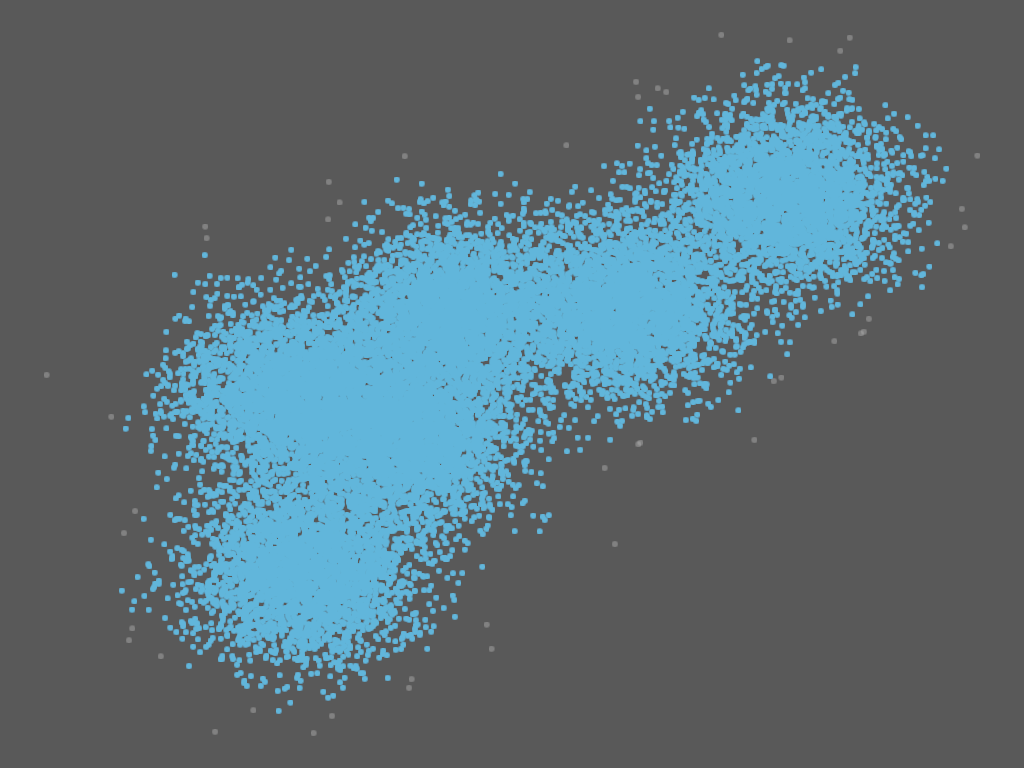

In [7]:
try:
    from sklearn.datasets import make_blobs
    from sklearn.cluster import DBSCAN

    X, y_true = make_blobs(n_samples=20_000, centers=6, cluster_std=1.2, random_state=0)
    X = X.astype(np.float32)

    db = DBSCAN(eps=0.6, min_samples=10).fit(X)
    labels = db.labels_.astype(np.int32)
    n_clusters = len(set(labels)) - (1 if -1 in labels else 0)
    n_noise    = np.sum(labels == -1)
    print(f"{n_clusters} clusters found, {n_noise} noise points")

    img = jv.clusters(X, labels=labels, size=3.0, width=1024, height=768)
    display(Image.fromarray(img, mode='RGBA'))

except ImportError:
    print("scikit-learn not installed — skipping this cell")

In [6]:
!uv pip install scikit-learn

Using Python 3.12.3 environment at: /home/skrsan/Documents/Projects/viz_primitive/.venv
Resolved 5 packages in 64ms                                          
Installed 3 packages in 15ms                                
 + joblib==1.5.3
 + scikit-learn==1.8.0
 + threadpoolctl==3.6.0
